<a href="https://colab.research.google.com/github/Faisalmalik01/deeplearning/blob/main/Handling_imbalanced_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

This cell imports necessary libraries for data manipulation and visualization. `pandas` is used for working with DataFrames, `matplotlib.pyplot` for plotting, and `numpy` for numerical operations. `%matplotlib inline` is a magic command specific to Jupyter/Colab notebooks that ensures plots are displayed directly below the code cell.

In [10]:
df = pd.read_csv("sample_data/customer_churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2823,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4698,8166-ZZTFS,Female,1,Yes,No,66,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),80.55,5265.1,Yes
6289,9053-JZFKV,Male,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),116.20,7752.3,Yes
22,1066-JKSGK,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
3210,9055-MOJJJ,Female,0,Yes,Yes,64,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Mailed check,65.80,4068,No


This cell loads the `customer_churn.csv` dataset into a pandas DataFrame named `df`. It then displays 5 random rows from the DataFrame using `df.sample(5)` to give a quick overview of the data's structure and content.

In [11]:
if 'customerID' in df.columns:
    df.drop('customerID', axis='columns', inplace=True)
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


Here, the `customerID` column is dropped from the DataFrame `df` if it exists, as it's typically an identifier and not useful for modeling directly. `inplace=True` modifies the DataFrame directly. Finally, `df.dtypes` is used to display the data types of each column, which is important for identifying columns that might need type conversion.

In [12]:
df.TotalCharges.values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

This cell accesses the `TotalCharges` column of the DataFrame `df` and displays its values. This step is likely taken to inspect the raw data in this column and understand its current format before any processing.

In [13]:
df.MonthlyCharges.values

array([ 29.85,  56.95,  53.85, ...,  29.6 ,  74.4 , 105.65])

Similar to the previous cell, this code accesses and displays the values of the `MonthlyCharges` column. This helps in understanding the data in this numerical column.

In [14]:
pd.to_numeric(df.TotalCharges, errors="coerce").isnull()

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


This cell attempts to convert the `TotalCharges` column to a numeric type using `pd.to_numeric`. The `errors='coerce'` argument ensures that any values that cannot be converted to a number are turned into `NaN` (Not a Number). `.isnull()` then checks which of these converted values are `NaN`, revealing rows where `TotalCharges` might contain non-numeric data.

In [15]:
df[pd.to_numeric(df.TotalCharges, errors="coerce").isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Building on the previous check, this cell filters the DataFrame `df` to show only the rows where `TotalCharges` could not be converted to a numeric type (i.e., where `pd.to_numeric(df.TotalCharges, errors='coerce').isnull()` is True). This allows for a closer inspection of the problematic entries.

In [16]:
df[pd.to_numeric(df.TotalCharges, errors="coerce").isnull()].shape

(11, 20)

This cell calculates and displays the shape (number of rows, number of columns) of the filtered DataFrame from the previous step. This confirms how many rows contain non-numeric values in the `TotalCharges` column.

In [17]:
df.shape

(7043, 20)

This cell displays the overall shape of the original `df` DataFrame, showing the total number of rows and columns before any specific filtering related to `TotalCharges` was applied.

In [18]:
df.iloc[488]['TotalCharges']

' '

This cell specifically retrieves and displays the `TotalCharges` value for the row at index 488. This is likely done to examine one of the problematic `TotalCharges` entries identified in previous steps (which turned out to be a space ' '). This helps in understanding why it couldn't be converted to a numeric type.

In [19]:
df1 = df[df.TotalCharges != ' ']
df1.shape

(7032, 20)

This cell creates a new DataFrame `df1` by filtering out rows from `df` where the `TotalCharges` column contains a space (' '). This effectively removes the problematic entries. The shape of the new `df1` is then printed to confirm the number of remaining rows.

In [20]:
df1.dtypes


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


This cell displays the data types of all columns in the `df1` DataFrame. This is an important step to ensure that `TotalCharges` is still an 'object' type before proceeding to convert it to numeric.

In [21]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

/tmp/ipykernel_2930/973151263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.TotalCharges = pd.to_numeric(df1.TotalCharges)


Here, the `TotalCharges` column in `df1` is finally converted to a numeric (float64) data type using `pd.to_numeric`. Since the rows with spaces were removed in the previous step, this conversion should now succeed without errors. The `SettingWithCopyWarning` is a common pandas warning and can often be ignored in this context.

This cell confirms that the `TotalCharges` column in `df1` has been successfully converted to a `float64` data type, which is a numerical type suitable for calculations.

In [22]:
df1.TotalCharges.dtypes

dtype('float64')

In [23]:
df1[df1.Churn=='No']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,Female,0,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


This cell filters the `df1` DataFrame to show only the rows where the `Churn` column has a value of 'No'. This is an intermediate step to prepare for visualizing the distribution of `tenure` for non-churning customers.

/tmp/ipykernel_2930/1343170738.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


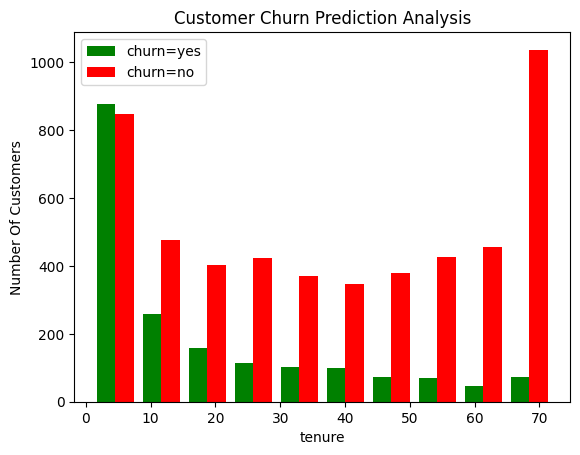

In [24]:
tenure_churn_no = df1[df1.Churn=='No'].tenure
tenure_churn_yes = df1[df1.Churn=='Yes'].tenure

plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Analysis")
plt.legend()

plt.hist([tenure_churn_yes, tenure_churn_no], color=['green', 'red'], label=['churn=yes', 'churn=no'])
plt.legend()

This cell generates a histogram to visualize the distribution of `tenure` (how long a customer has been with the company) for both churning ('Yes') and non-churning ('No') customers. It helps to understand if `tenure` plays a role in customer churn. The `plt.hist` function takes a list of data arrays and plots them side-by-side with different colors and labels.

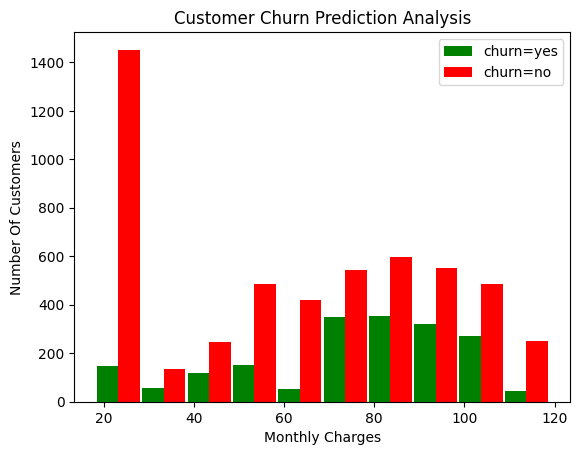

In [25]:
mc_churn_no = df1[df1.Churn=='No'].MonthlyCharges
mc_churn_yes = df1[df1.Churn=='Yes'].MonthlyCharges

plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Analysis")


blood_sugar_men = [113,85,90,150,149,88,93,115,135,80,77,82,129]
blood_sugar_women = [67,98,89,120,133,150,84,69,89,79,120,112,100]

plt.hist([mc_churn_yes, mc_churn_no],rwidth=0.95, color=['green', 'red'], label=['churn=yes', 'churn=no'])
plt.legend()



Similar to the previous cell, this cell creates a histogram to visualize the distribution of `MonthlyCharges` for churning and non-churning customers. This helps to identify if higher or lower monthly charges correlate with churn behavior. The `rwidth` parameter adds a small gap between bars for better readability.

In [26]:
for column in df:
  print(column)

gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


This cell iterates through all column names in the DataFrame `df` and prints each column name. This is a simple way to list all features available in the dataset.

In [27]:
def print_unique_col_values(df):
  for column in df:
    if df[column].dtypes=='object':
      print(f'{column}: {df[column].unique()}')

This cell defines a helper function `print_unique_col_values` that takes a DataFrame as input. It then iterates through each column and if the column's data type is 'object' (meaning it's likely a categorical string column), it prints the column name along with its unique values. This is useful for inspecting categorical features and identifying potential inconsistencies or values that need encoding.

In [28]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


This cell calls the `print_unique_col_values` function defined previously, passing `df1` as the DataFrame. This will display the unique values for all object-type columns in `df1`, helping to understand the distinct categories within each feature.

In [29]:
df1.replace('No internet service', 'No', inplace=True)
df1.replace('No phone service', 'No', inplace=True)

/tmp/ipykernel_2930/4245438437.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No internet service', 'No', inplace=True)
/tmp/ipykernel_2930/4245438437.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.replace('No phone service', 'No', inplace=True)


This cell performs data cleaning by replacing specific string values in `df1`. It replaces 'No internet service' with 'No' and 'No phone service' with 'No' across all columns. This consolidates similar categories into a single 'No' category, simplifying the data for modeling. The `inplace=True` argument applies these changes directly to `df1`.

In [30]:
print_unique_col_values(df1)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


After the replacement operations, this cell calls `print_unique_col_values` again to verify that 'No internet service' and 'No phone service' are no longer present in the unique values of the object-type columns, confirming the cleaning step was successful.

In [31]:
yes_no_columns = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in yes_no_columns:
  df1[col].replace({'Yes':1, 'No':0}, inplace=True)


/tmp/ipykernel_2930/3058007921.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1[col].replace({'Yes':1, 'No':0}, inplace=True)
/tmp/ipykernel_2930/3058007921.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[col].replace({'Yes':1, 'No':0}, inplace=True)
/tmp/ipykernel_2930/3058007921.py:

This cell identifies a list of 'yes/no' type columns that contain string values ('Yes'/'No'). It then iterates through these columns and replaces 'Yes' with 1 and 'No' with 0. This converts binary categorical features into numerical representations, which is required for most machine learning algorithms. The `inplace=True` argument directly modifies the DataFrame.

In [32]:
for col in df1:
  print(f'{col}: {df1[col].unique()}')

gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: [0 1]
MultipleLines: [0 1]
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: [1 0]
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]


This cell iterates through all columns in `df1` and prints the unique values for each. This is a comprehensive check to see the effect of the previous data transformations, especially the conversion of 'Yes'/'No' to 1/0.

In [33]:
df1['gender'].replace({'Female':1, 'Male':0}, inplace=True)

/tmp/ipykernel_2930/3951318906.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['gender'].replace({'Female':1, 'Male':0}, inplace=True)
/tmp/ipykernel_2930/3951318906.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['gender'].replace({'Female':1, 'Male':0}, inplace=True)
/tmp/ipykernel

This cell specifically converts the 'gender' column from categorical strings ('Female', 'Male') to numerical representations (1 for 'Female', 0 for 'Male'). This is a common step for binary categorical features before feeding them into machine learning models.

In [34]:
df1['gender'].unique()

array([1, 0])

This cell displays the unique values in the 'gender' column after the conversion. It confirms that the column now contains only 0s and 1s, representing 'Male' and 'Female' respectively.

In [35]:
df2 = pd.get_dummies(data=df1,columns=['InternetService', 'Contract', 'PaymentMethod'])

# Convert boolean columns to int (0s and 1s)
for col in df2.columns:
    if df2[col].dtype == 'bool':
        df2[col] = df2[col].astype(int)

df2.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

This cell uses `pd.get_dummies` to perform one-hot encoding on the specified categorical columns: 'InternetService', 'Contract', and 'PaymentMethod'. This converts these nominal categorical variables into a numerical format suitable for machine learning by creating new binary columns for each category. It then converts any resulting boolean columns to integers (0s and 1s) to ensure consistency. Finally, `df2.columns` displays the names of all columns in the new DataFrame, including the newly created dummy variables.

In [36]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3599,Female,0,Yes,Yes,45,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,No,Month-to-month,No,Mailed check,81.30,3541.1,No
4436,Female,0,No,Yes,19,Yes,No,DSL,Yes,Yes,Yes,No,No,No,Month-to-month,Yes,Electronic check,60.60,1297.8,No
3745,Male,0,No,No,7,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,94.25,669,Yes
5382,Male,0,Yes,Yes,56,No,No phone service,DSL,Yes,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,52.00,2884.9,No
2733,Female,0,Yes,No,1,Yes,No,DSL,No,No,No,No,Yes,No,Month-to-month,Yes,Mailed check,55.30,55.3,No


This cell displays 5 random rows from the original `df` DataFrame. This is likely an intermittent check to compare the original data with the transformed `df2` DataFrame to ensure that `df` remains unchanged for reference or further operations.

In [37]:
df2.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64


This cell displays the data types of all columns in the `df2` DataFrame. This is a crucial step after extensive data transformation (like one-hot encoding and binary conversion) to ensure that all columns are in appropriate numerical formats for model training.

In [38]:
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges'] # Define a list of numerical columns to be scaled

from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler for feature scaling
scaler = MinMaxScaler() # Create an instance of MinMaxScaler
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale]) # Apply Min-Max scaling to the selected columns in df2

This cell performs feature scaling on the numerical columns 'tenure', 'MonthlyCharges', and 'TotalCharges' using `MinMaxScaler`. Min-Max scaling transforms the values to a range between 0 and 1. This is important for many machine learning algorithms, especially neural networks, as it helps prevent features with larger values from dominating the learning process. The `fit_transform` method fits the scaler to the data and then transforms it in one step.

In [39]:
df2.sample(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4056,1,0,0,0,0.028169,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
510,0,1,1,1,0.267606,1,0,1,0,1,...,0,1,0,0,1,0,0,1,0,0
4111,1,0,0,0,0.295775,1,0,0,1,1,...,1,0,0,0,1,0,1,0,0,0


This cell displays 3 random rows from the `df2` DataFrame after feature scaling. This allows for a quick visual inspection to confirm that the numerical columns now have values scaled between 0 and 1.

In [40]:
for col in df2:
  print(f'{col}: {df2[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [0.         0.46478873 0.01408451 0.61971831 0.09859155 0.29577465
 0.12676056 0.38028169 0.85915493 0.16901408 0.21126761 0.8028169
 0.67605634 0.33802817 0.95774648 0.71830986 0.98591549 0.28169014
 0.15492958 0.4084507  0.64788732 1.         0.22535211 0.36619718
 0.05633803 0.63380282 0.14084507 0.97183099 0.87323944 0.5915493
 0.1971831  0.83098592 0.23943662 0.91549296 0.11267606 0.02816901
 0.42253521 0.69014085 0.88732394 0.77464789 0.08450704 0.57746479
 0.47887324 0.66197183 0.3943662  0.90140845 0.52112676 0.94366197
 0.43661972 0.76056338 0.50704225 0.49295775 0.56338028 0.07042254
 0.04225352 0.45070423 0.92957746 0.30985915 0.78873239 0.84507042
 0.18309859 0.26760563 0.73239437 0.54929577 0.81690141 0.32394366
 0.6056338  0.25352113 0.74647887 0.70422535 0.35211268 0.53521127]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [

This cell iterates through all columns in the scaled `df2` DataFrame and prints the unique values for each. This is a final check to ensure that all columns are numerical and that the scaling has been applied correctly to the selected columns, with values typically ranging from 0 to 1 (or 0 and 1 for binary encoded columns).

In [41]:
x = df2.drop('Churn', axis='columns')
y = df2['Churn']

This cell splits the `df2` DataFrame into features (`x`) and the target variable (`y`). `x` contains all columns except 'Churn', which is the feature matrix for training. `y` contains only the 'Churn' column, which is the target variable to be predicted.

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=15, stratify=y)

This cell splits the dataset into training and testing sets using `train_test_split` from `sklearn.model_selection`. `test_size=0.2` allocates 20% of the data for testing, `random_state=15` ensures reproducibility of the split, and `stratify=y` ensures that the proportion of churned vs. non-churned customers is maintained in both the training and testing sets, which is crucial for imbalanced datasets.

In [43]:
y_train.value_counts()

,count
Churn,
0,4130
1,1495


This cell uses `value_counts()` on the `y_train` series to show the distribution of the target variable ('Churn') in the training set. This helps confirm the class balance (or imbalance) within the training data.

In [44]:
y.value_counts()

,count
Churn,
0,5163
1,1869


This cell uses `value_counts()` on the entire `y` series (the target variable before splitting) to show the overall distribution of churned vs. non-churned customers in the dataset. This helps to identify if there is a class imbalance.

In [45]:
5163/1869

2.7624398073836276

This cell calculates the ratio of the two classes (non-churned to churned customers) based on the total counts. This quantifies the degree of class imbalance in the dataset.

In [46]:
y_test.value_counts()

,count
Churn,
0,1033
1,374


This cell displays the distribution of the target variable ('Churn') in the `y_test` set using `value_counts()`. This confirms that the test set also maintains a similar class distribution due to the `stratify` parameter used in `train_test_split`.

theres is an imbalance

This markdown cell explicitly states that there is an imbalance in the dataset, referring to the unequal distribution of churned and non-churned customers.

In [47]:
x_train.shape


(5625, 26)

This cell displays the shape (number of rows, number of columns) of the `x_train` DataFrame, which contains the features for the training set. This confirms the dimensions of the input data for model training.

In [48]:
x_test.shape

(1407, 26)

This cell displays the shape of the `x_test` DataFrame, which contains the features for the testing set. This confirms the dimensions of the input data for model evaluation.

In [49]:
x_train[:10]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
684,1,0,0,0,0.000000,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
2446,1,0,0,0,0.239437,1,1,0,1,0,...,0,1,0,1,0,0,0,1,0,0
1680,0,0,1,1,0.774648,1,1,0,0,0,...,0,0,1,0,1,0,0,0,0,1
2220,0,0,1,0,1.000000,1,0,1,1,0,...,1,0,0,0,0,1,1,0,0,0
2842,1,0,0,0,0.042254,0,0,1,0,1,...,1,0,0,1,0,0,0,0,0,1
5131,1,0,1,0,0.605634,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4372,0,0,1,1,0.000000,1,0,0,0,0,...,0,0,1,1,0,0,1,0,0,0
4687,0,0,1,0,0.295775,1,0,0,0,1,...,0,1,0,1,0,0,0,1,0,0
2385,1,0,0,1,0.028169,0,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
6773,0,1,1,0,0.507042,1,1,0,0,0,...,0,1,0,1,0,0,0,0,1,0


This cell displays the first 10 rows of the `x_train` DataFrame, providing a glimpse of the processed and scaled features that will be used to train the model.

In [50]:
len(x_train.columns)

26

This cell calculates and displays the number of columns (features) in the `x_train` DataFrame. This value is important for defining the `input_dim` of the first layer in the neural network.

In [51]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report

This cell imports necessary libraries for building and evaluating an Artificial Neural Network (ANN). `tensorflow` and `keras` are used for creating the neural network model, and `confusion_matrix` and `classification_report` from `sklearn.metrics` are used for evaluating the model's performance.

In [52]:
def ANN(x_train, y_train, x_test, y_test, loss, weights):
  model = keras.Sequential([
    keras.layers.Dense(26, input_dim=len(x_train.columns), activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
  ])

  model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

  if weights == -1:
    model.fit(x_train, y_train, epochs=100)
  else:
    model.fit(x_train, y_train, epochs=100)

  print(model.evaluate(x_test, y_test))

  y_pred = model.predict(x_test)
  y_pred = np.round(y_pred)

  print("Classification Report: \n", classification_report(y_test, y_pred))

  return y_pred

This cell defines the `ANN` function, which constructs, compiles, trains, and evaluates a simple Artificial Neural Network.
- **Model Architecture**: It creates a sequential Keras model with three dense layers. The first hidden layer has 26 neurons (matching the number of input features), the second has 15 neurons, both using 'relu' activation. The output layer has 1 neuron with 'sigmoid' activation for binary classification.
- **Compilation**: The model is compiled using the 'adam' optimizer, 'binary_crossentropy' as the loss function (suitable for binary classification), and 'accuracy' as the evaluation metric.
- **Training**: It trains the model for 100 epochs using the provided training data. The `weights` parameter is not fully utilized here but suggests a potential for weighted loss.
- **Evaluation**: After training, it evaluates the model's performance on the test set and prints the loss and accuracy.
- **Prediction and Report**: It then makes predictions on the test set, rounds them to 0 or 1, and prints a `classification_report` which includes precision, recall, f1-score, and support for each class.

In [53]:
y_preds = ANN(x_train, y_train, x_test, y_test, 'binary_crossentropy', -1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7141 - loss: 0.5379
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7831 - loss: 0.4426
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7883 - loss: 0.4294
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7945 - loss: 0.4232
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7972 - loss: 0.4197
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8012 - loss: 0.4173
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8027 - loss: 0.4151
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8014 - loss: 0.4136
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8062 - loss: 0.4122
Epoch 10/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8041 - loss: 0.4113
Epoch 11/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8043 - loss: 0.4085
Epoch 12/100
176/176 ━━━━━━━━━━━━━━━━━━━━

This cell calls the `ANN` function with the prepared training and testing data, 'binary_crossentropy' as the loss function, and -1 for the `weights` parameter (though its functionality is not fully implemented in the current `ANN` definition). The returned predictions are stored in `y_preds`.

In [54]:
# class count
count_class_0, count_class_1 = df.Churn.value_counts()

# Divide by class
df_class_0 = df2[df2['Churn'] == 0]
df_class_1 = df2[df2['Churn'] == 1]

This cell calculates the counts of each class (0 and 1) in the 'Churn' column of the original `df` DataFrame. It then creates two new DataFrames, `df_class_0` and `df_class_1`, by separating the `df2` DataFrame based on the 'Churn' value. This is a preparatory step for handling class imbalance using techniques like under-sampling or over-sampling.

In [55]:
count_class_0, count_class_1

(5174, 1869)

This cell simply prints the `count_class_0` and `count_class_1` variables, showing the number of non-churned and churned customers, respectively. This reiterates the class imbalance observed earlier.

In [56]:
df_class_0.shape

(5163, 27)

This cell displays the shape (number of rows, number of columns) of `df_class_0`, confirming the number of non-churned customer records.

In [57]:
df_class_1.shape

(1869, 27)

This cell displays the shape of `df_class_1`, confirming the number of churned customer records. This further highlights the class imbalance.

imbalance - one class had 5163 2nd class has 1869 samples

This markdown cell explicitly notes the class imbalance, pointing out the significant difference in the number of samples between the two classes (5163 vs. 1869).

1.Under Sampling

This markdown cell introduces the next technique to be applied: Under Sampling, which is a method to address class imbalance by reducing the number of samples in the majority class.

In [58]:
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

print("Random under-sampling:")
print(df_test_under.Churn.value_counts())
df_test_under.shape

Random under-sampling:
Churn
0    1869
1    1869
Name: count, dtype: int64


(3738, 27)

This cell implements random under-sampling. It samples `count_class_1` (the number of samples in the minority class) from `df_class_0` (the majority class) to create `df_class_0_under`. Then, it concatenates `df_class_0_under` with `df_class_1` to create a new balanced DataFrame `df_test_under`. Finally, it prints the value counts of the 'Churn' column in `df_test_under` and its shape to confirm that the classes are now balanced.

In [59]:
x = df_test_under.drop('Churn', axis='columns')
y = df_test_under['Churn']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=15, stratify=y)



This cell prepares the data for training with the under-sampled dataset. It separates the features (`x`) and the target variable (`y`) from `df_test_under`. Then, it splits this balanced dataset into training and testing sets using `train_test_split`, again using `test_size=0.2`, `random_state=15`, and `stratify=y` to maintain the class balance within the split sets.

In [60]:
y_train.value_counts()

,count
Churn,
0,1495
1,1495


This cell displays the value counts of the 'Churn' column in the `y_train` set after under-sampling and splitting. This confirms that the training set for the under-sampled model now has an equal number of samples for both classes.

In [61]:
y_preds = ANN(x_train, y_train, x_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6381 - loss: 0.6468
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7425 - loss: 0.5227
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7548 - loss: 0.5009
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7592 - loss: 0.4935
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7662 - loss: 0.4894
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7662 - loss: 0.4851
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7676 - loss: 0.4826
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7666 - loss: 0.4807
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7669 - loss: 0.4782
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7666 - loss: 0.4762
Epoch 11/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7689 - loss: 0.4752
Epoch 12/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7722 - lo

This cell calls the `ANN` function again, this time using the training and testing data derived from the under-sampled dataset. The purpose is to observe how the neural network performs on a balanced dataset compared to the imbalanced one. The predictions from this model are stored in `y_preds`.

Method 2: Oversampling

This markdown cell introduces 'Method 2: Oversampling', an alternative technique to address class imbalance. Oversampling involves increasing the number of instances in the minority class to match the majority class.

In [75]:
count_class_0, count_class_1

(5174, 1869)

This cell prints the previously calculated counts for the majority (`count_class_0`) and minority (`count_class_1`) classes. This serves as a reminder of the original class distribution before applying oversampling.

In [74]:
df_class_1.shape

(1869, 27)

This cell displays the shape of the `df_class_1` DataFrame, which contains only the minority class (churned customers). This confirms the number of minority samples available.

In [73]:
df_class_1.sample(200).shape

(200, 27)

This cell demonstrates taking a small sample (200 rows) from the `df_class_1` DataFrame and displays its shape. This is likely an exploratory step to understand how `df.sample()` works before applying it for oversampling the entire minority class.

In [78]:
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print("Random over-sampling:")
print(df_test_over.Churn.value_counts())


Random over-sampling:
Churn
1    5174
0    5163
Name: count, dtype: int64


(10337, 27)

This cell implements random over-sampling. It samples from the minority class (`df_class_1`) an amount equal to the majority class count (`count_class_0`), with `replace=True` to allow for duplicate samples. This creates `df_class_1_over`. It then concatenates this oversampled minority class with the original majority class (`df_class_0`) to form the new balanced DataFrame `df_test_over`. Finally, it prints the value counts of the 'Churn' column and the shape of `df_test_over` to verify the new balanced distribution and total number of samples.

In [79]:
x = df_test_over.drop('Churn', axis='columns')
y = df_test_over['Churn']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=15, stratify=y)

This cell prepares the data for training with the oversampled dataset. It separates the features (`x`) and the target variable (`y`) from `df_test_over`. Subsequently, it splits this balanced dataset into training and testing sets using `train_test_split`. `test_size=0.2` allocates 20% for testing, `random_state=15` ensures reproducibility, and `stratify=y` maintains the class balance within both the training and testing sets.

In [80]:
y_train.value_counts()

,count
Churn,
1,4139
0,4130


This cell displays the value counts of the 'Churn' column in the `y_train` set after oversampling and splitting. This confirms that the training set for the oversampled model now has an approximately equal number of samples for both classes, albeit with a slightly larger total dataset.

In [81]:
y_train.value_counts()

,count
Churn,
1,4139
0,4130


This cell is a duplicate of the previous cell and again displays the value counts of the 'Churn' column in `y_train`, confirming the class distribution in the training data for the oversampled model.

In [82]:
y_preds = ANN(x_train, y_train, x_test, y_test, 'binary_crossentropy', -1)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7372 - loss: 0.5502
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7591 - loss: 0.4934
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7616 - loss: 0.4872
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7658 - loss: 0.4806
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7673 - loss: 0.4766
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7695 - loss: 0.4726
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7786 - loss: 0.4689
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7764 - loss: 0.4651
Epoch 9/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7786 - loss: 0.4637
Epoch 10/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7816 - loss: 0.4608
Epoch 11/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7828 - loss: 0.4584
Epoch 12/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

This cell calls the `ANN` function with the training and testing data derived from the oversampled dataset. This runs the Artificial Neural Network model on the newly balanced data. The purpose is to observe how the neural network performs on a dataset where the minority class has been increased. The `y_preds` variable will store the predictions from this model.

Method 3: SMOTE

This markdown cell introduces 'Method 3: SMOTE' (Synthetic Minority Over-sampling Technique), another approach to handle class imbalance. SMOTE works by creating synthetic samples for the minority class, rather than simply duplicating existing ones, which can help in generalizing the model better.

In [84]:
x = df2.drop('Churn', axis='columns')
y = df2['Churn']

This cell re-initializes the feature matrix `x` (all columns except 'Churn') and the target variable `y` (the 'Churn' column) from the `df2` DataFrame. This ensures that we are starting with the original, imbalanced dataset before applying SMOTE.

In [85]:
y.value_counts()

,count
Churn,
0,5163
1,1869


This cell displays the value counts of the 'Churn' column in the `y` series, showing the original class distribution and confirming the imbalance before applying SMOTE.

In [86]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x, y)

y_sm.value_counts()

,count
Churn,
0,5163
1,5163


This cell applies the SMOTE (Synthetic Minority Over-sampling Technique) algorithm to balance the dataset. `SMOTE(sampling_strategy='minority')` generates new synthetic samples for the minority class until it matches the number of samples in the majority class. The resulting balanced features and target are stored in `x_sm` and `y_sm`, respectively. Finally, `y_sm.value_counts()` is printed to confirm the new, balanced class distribution.

In [88]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)


This cell splits the SMOTE-generated balanced dataset (`x_sm`, `y_sm`) into training and testing sets using `train_test_split`. `test_size=0.2` allocates 20% of the data for testing, `random_state=15` ensures reproducibility of the split, and `stratify=y_sm` ensures that the balanced proportion of churned vs. non-churned customers is maintained in both the training and testing sets.

In [89]:
y_train.value_counts()

,count
Churn,
1,4130
0,4130


This cell displays the value counts of the 'Churn' column in the `y_train` set after applying SMOTE and splitting the data. This confirms that the training set now has an equal number of samples for both classes, which is crucial for training a fair model on a balanced dataset.

In [90]:
y_test.value_counts()

,count
Churn,
1,1033
0,1033


This cell displays the value counts of the 'Churn' column in the `y_test` set after applying SMOTE and splitting the data. This confirms that the test set also maintains an equal number of samples for both classes, ensuring a representative evaluation of the model's performance on balanced data.

In [91]:
y_preds = ANN(x_train, y_train, x_test, y_test, 'binary_crossentropy', -1)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7098 - loss: 0.5555
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7817 - loss: 0.4680
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7815 - loss: 0.4604
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7881 - loss: 0.4534
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7914 - loss: 0.4495
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7919 - loss: 0.4455
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7932 - loss: 0.4415
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7935 - loss: 0.4383
Epoch 9/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7982 - loss: 0.4342
Epoch 10/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8001 - loss: 0.4302
Epoch 11/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7999 - loss: 0.4286
Epoch 12/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

This cell calls the `ANN` function with the training and testing data derived from the SMOTE-oversampled dataset. This runs the Artificial Neural Network model on the newly balanced data. The purpose is to observe how the neural network performs on a dataset where synthetic samples have been created for the minority class, potentially leading to improved generalization. The `y_preds` variable will store the predictions from this model.